# Trabalho desenvolvido no Âmbito da disciplina [Aprendizagem Computacional Avançada] por José Cunha e Marta Antunes

# Projeto Denoising Autoencoder (DAE) - BloodMNIST

## Visão Geral do Projeto

Este projeto implementa e experimenta com Denoising Autoencoders (DAE) usando o dataset BloodMNIST.  
O objetivo principal é treinar um modelo capaz de reconstruir imagens limpas a partir de versões com ruído, e posteriormente explorar as suas capacidades de geração de novas imagens.

## Estrutura do Projeto

### Duas Abordagens Implementadas

**Código 1: DAE para Reconstrução (Abordagem Educacional)**  
- **Objetivo:** Treinar um DAE para remover ruído de imagens  
- **Input:** Imagens com ruído Gaussiano (σ = 0.2)  
- **Target:** Imagens originais limpas  
- **Avaliação:** FID entre imagens reconstruídas e originais  
- **Uso:** Esta é a aplicação principal e correta de um DAE  

**Código 2: DAE para Geração (Exploração Experimental)**  
- **Objetivo:** Tentar usar o DAE treinado para gerar novas imagens  
- **Input:** Ruído Gaussiano puro  
- **Target:** Novas imagens sintéticas  
- **Limitações:** DAEs não são ideais para geração, mas é uma exploração interessante  

## Objetivos de Aprendizagem

- Compreender autoencoders: Arquitetura encoder-decoder  
- Denoising: Como treinar modelos para remover ruído  
- Limitações: Entender por que DAEs não são ideais para geração  
- Métricas: Usar FID para avaliar qualidade de imagens  
- Comparação: Ver diferenças entre reconstrução vs geração  

## Dataset: BloodMNIST

- **Fonte:** Medical MNIST collection  
- **Tipo:** Imagens de células sanguíneas  
- **Dimensões:** 28x28x3 (RGB)  
- **Classes:** 8 tipos diferentes de células  
- **Total:** ~17.000 imagens (train + val + test)  

## Arquitetura do Modelo

### Encoder
- Input (3x28x28)  
- Conv2d(3→64) + BatchNorm + ReLU  
- Conv2d(64→128, stride=2) + BatchNorm + ReLU  → 28x28 → 14x14  
- Conv2d(128→256, stride=2) + BatchNorm + ReLU → 14x14 → 7x7  

### Decoder
- Latent (256x7x7)  
- ConvTranspose2d(256→128, stride=2) + BatchNorm + ReLU → 7x7 → 14x14  
- ConvTranspose2d(128→64, stride=2) + BatchNorm + ReLU → 14x14 → 28x28  
- Conv2d(64→3) + Tanh → Output (3x28x28)  

## Função de Loss Combinada

Loss = 0.5 × MSE + 0.3 × L1 + 0.2 × (1 - SSIM)


* **MSE:** Erro quadrático médio (diferenças pixel-level)
* **L1:** Erro absoluto médio (robustez a outliers)
* **SSIM:** Similaridade estrutural (percepção visual)

## Hiperparâmetros

* **Learning Rate:** 1e-4
* **Optimizer:** Adam (β₁ = 0.9, β₂ = 0.999)
* **Batch Size:** 256 (GPU) / 128 (CPU)
* **Epochs:** 150 (com early stopping)
* **Noise Level:** σ = 0.2 (Gaussiano)
* **Scheduler:** ReduceLROnPlateau

## Próximos Passos

1. Executar Código 1: Treinar DAE para reconstrução
2. Analisar Resultados: Verificar qualidade de denoising
3. Executar Código 2: Experimentar com geração
4. Comparar: Entender diferenças e limitações
5. Relatório: Documentar aprendizagens e conclusões

## Notas Importantes

* O Código 1 representa o uso correto de DAEs
* O Código 2 é experimental - DAEs não são GANs
* Para geração, considera VAEs ou GANs em projetos futuros
* Sempre analise os gráficos de treino para detectar overfitting
* FID mais baixo = melhor qualidade de imagem



# Importação das Bibliotecas

Nesta seção, são importadas todas as bibliotecas necessárias para o desenvolvimento e execução do modelo de difusão.

---

In [ ]:
# --- Install required libraries ---
!pip install torch torchvision matplotlib medmnist pytorch-fid --quiet
!pip install 'torchmetrics[image]'
!pip install torch torchvision torchmetrics medmnist matplotlib tqdm
!pip install medmnist torch torchvision tensorboard

from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import ConcatDataset

import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import torchvision.transforms.functional as F

import medmnist
from medmnist import INFO, Evaluator

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 19.3 MB/s eta 0:00:00


# Código 1: DAE para Reconstrução de Imagens

## Objetivo Principal

Este código implementa um **Denoising Autoencoder (DAE)** para a sua aplicação principal: **remoção de ruído de imagens**. O modelo aprende a reconstruir imagens limpas a partir de versões corrompidas com ruído Gaussiano.

## Fluxo de Funcionamento

### 1. Preparação dos Dados

```python
# Imagem limpa original
clean_image = BloodMNIST_sample

# Adicionar ruído durante o treino
noisy_image = clean_image + torch.randn_like(clean_image) * 0.2

# Input: imagem ruidosa → Output: imagem limpa
````

### 2. Processo de Treino

```
Input (Ruidosa) → Encoder → Latent Space → Decoder → Output (Reconstruída)
                                                           ↓
                                            Loss vs Original (Limpa)
```

### 3. Avaliação

* **FID**: Compara imagens reconstruídas com originais limpas
* **Visualização**: Triplets (limpa, ruidosa, reconstruída)
* **Métricas**: MSE + L1 + SSIM loss

## Características Específicas

### Gestão de Dados

* **Dois transforms**:

  * `clean_transform`: Para imagens de referência
  * `data_transform`: Para treino (mesmo transform, ruído adicionado dinamicamente)
* **Concat Dataset**: Combina train + val + test para mais dados

### Função de Loss Avançada

```python
def dae_loss(recon_x, x):
    mse_loss = F.mse_loss(recon_x, x, reduction='sum')      # Precisão pixel-level
    l1_loss = F.l1_loss(recon_x, x, reduction='sum')        # Robustez
    ssim_loss = (1 - ssim(recon_x, x)) * recon_x.numel()    # Percepção visual
    
    return 0.5 * mse_loss + 0.3 * l1_loss + 0.2 * ssim_loss
```

### Avaliação FID Específica para DAE

```python
def compute_fid_safe(model, num_samples=10000):
    # Compara:
    # Real: Imagens limpas originais
    # Fake: Imagens reconstruídas pelo DAE (a partir de ruidosas)
```

## Resultados Esperados

### Visualizações Geradas

1. **Comparison Grids**: Lado a lado (limpa, ruidosa, reconstruída)
2. **Training Curves**: Loss de treino ao longo das épocas
3. **FID Evolution**: Melhoria da qualidade durante treino

### Ficheiros de Saída

* `best_dae_epoch{X}_fid{Y}.pth`: Melhor modelo
* `comparison_XXX.png`: 100 exemplos de reconstrução
* `training_results.png`: Gráficos de análise
* `results_summary.txt`: Relatório final

## Pontos de Atenção

### Early Stopping Inteligente

* Monitoriza FID em vez de apenas loss
* Paciência de 10 épocas para melhorias
* Guarda sempre o melhor modelo

### Gestão de Memória

* `torch.cuda.empty_cache()` entre avaliações FID
* Batch sizes otimizados para GPU disponível
* Pin memory para acelerar transfers

### Robustez na Avaliação

```python
# FID final com múltiplas execuções
for run in range(5):
    fid = compute_fid_safe(model, num_samples=10000)
    final_fid_scores.append(fid)

avg_fid = np.mean(final_fid_scores)  # Média das 5 execuções
std_fid = np.std(final_fid_scores)   # Desvio padrão
```

## Interpretação dos Resultados

### FID Score

* **< 50**: Excelente qualidade de reconstrução
* **50-100**: Boa qualidade
* **> 100**: Qualidade questionável

### Componentes da Loss

* **MSE dominante**: Foco em precisão pixel-level
* **L1 contribuição**: Reduz artifacts
* **SSIM**: Preserva estruturas importantes



## Limitações Conhecidas

1. **Não é geração**: Só reconstrói, não cria imagens novas
2. **Dependente do ruído**: Treinado especificamente para σ = 0.2
3. **Qualidade limitada**: DAEs têm limitações inerentes vs VAEs/GANs
4. **Blur effect**: Pode produzir imagens ligeiramente desfocadas

Este código representa o **uso correto e principal** de Denoising Autoencoders - a reconstrução de imagens limpas a partir de versões corrompidas com ruído.

Mounted at /content/drive


100%|██████████| 35.5M/35.5M [00:02<00:00, 16.6MB/s]


Starting DAE Training...


Epoch 1: 100%|██████████| 67/67 [00:02<00:00, 28.70it/s, loss=174]


Epoch time: 2.34s


...

Epoch time: 1.37s


Epoch 109: 100%|██████████| 67/67 [00:01<00:00, 47.30it/s, loss=81.1]


Epoch time: 1.42s


Epoch 110: 100%|██████████| 67/67 [00:01<00:00, 48.19it/s, loss=80]


Epoch 110/150 - Loss: 80.3931 - FID: 16.12
Early stopping at epoch 110

Generating denoised images for final evaluation...

Running final FID evaluation (5 runs with 10k samples)...

Run 1/5
FID = 9.71

Run 2/5
FID = 9.74

Run 3/5
FID = 9.65

Run 4/5
FID = 9.65

Run 5/5
FID = 9.61

⭐ Final FID: 9.67 ± 0.05


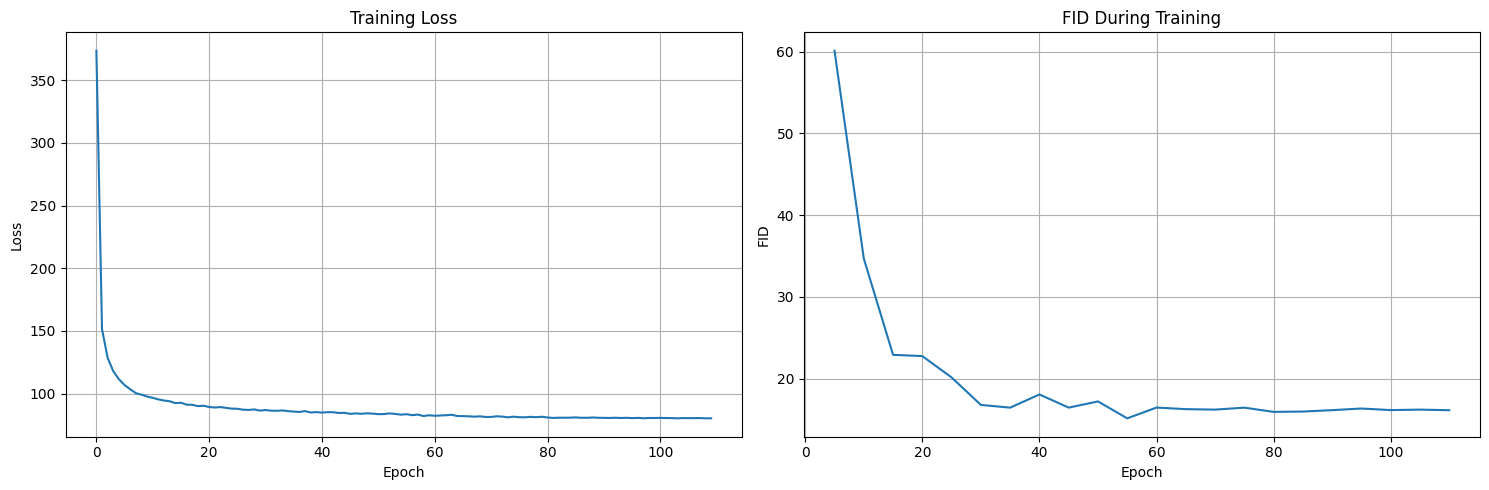


Training complete! All files saved to: /content/drive/MyDrive/Projeto2_DAE_20250526-180434
Best FID achieved: 15.13 at epoch 55
Final FID (10k samples): 9.67 ± 0.05


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import transforms, utils
from medmnist import BloodMNIST
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from torchmetrics.image.fid import FrechetInceptionDistance
import os
from google.colab import drive
from torchvision.utils import save_image
import time
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.image import StructuralSimilarityIndexMeasure

# 1. Configuration
drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

timestamp = time.strftime("%Y%m%d-%H%M%S")
project_path = f'/content/drive/MyDrive/Projeto2_DAE_{timestamp}'
os.makedirs(project_path, exist_ok=True)

model_dir = os.path.join(project_path, 'models')
images_dir = os.path.join(project_path, 'generated_images')
logs_dir = os.path.join(project_path, 'logs')
os.makedirs(model_dir, exist_ok=True)
os.makedirs(images_dir, exist_ok=True)
os.makedirs(logs_dir, exist_ok=True)

writer = SummaryWriter(logs_dir)

# 2. Data Loading with Noise Augmentation
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.2):
        self.std = std
        self.mean = mean

    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size(), device=tensor.device) * self.std + self.mean

    def __repr__(self):
        return self.__class__.__name__ + '(mean={0}, std={1})'.format(self.mean, self.std)

# Base transform without noise for clean images
clean_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Transform with augmentation and noise for training
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = BloodMNIST(split='train', transform=data_transform, download=True)
val_dataset = BloodMNIST(split='val', transform=data_transform, download=True)
test_dataset = BloodMNIST(split='test', transform=data_transform, download=True)
full_dataset = ConcatDataset([train_dataset, val_dataset, test_dataset])

batch_size = 256 if torch.cuda.is_available() else 128
dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

# 3. Fixed DAE Architecture with exact dimension matching
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder with padding to maintain dimensions
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # 28->14
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),  # 14->7
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        # Decoder with exact dimension matching
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),  # 7->14
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  # 14->28
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 3, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# 4. Training Functions
ssim = StructuralSimilarityIndexMeasure(data_range=2.0).to(device)

def dae_loss(recon_x, x):
    # Reconstruction loss with multiple components
    mse_loss = F.mse_loss(recon_x, x, reduction='sum')
    l1_loss = F.l1_loss(recon_x, x, reduction='sum')
    ssim_loss = (1 - ssim(recon_x, x)) * recon_x.numel()

    return 0.5*mse_loss + 0.3*l1_loss + 0.2*ssim_loss

def train_epoch(model, dataloader, optimizer, epoch):
    model.train()
    total_loss = 0

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}")

    for x, _ in progress_bar:
        x = x.to(device)
        optimizer.zero_grad()

        # Add noise to clean images
        noise = torch.randn_like(x) * 0.2
        noisy_x = x + noise

        # Forward pass with noisy input
        recon = model(noisy_x)

        # Compute loss against clean images
        loss = dae_loss(recon, x)
        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item()/len(x))

    avg_loss = total_loss / len(dataloader.dataset)
    writer.add_scalar('Loss/train', avg_loss, epoch)

    return avg_loss

def compute_fid_safe(model, num_samples=10000, batch_size=128):
    """FID calculation for DAE (compare denoised images with clean ones)"""
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    model.eval()

    # Process real clean images
    clean_dataset = ConcatDataset([
        BloodMNIST(split='train', transform=clean_transform, download=False),
        BloodMNIST(split='val', transform=clean_transform, download=False),
        BloodMNIST(split='test', transform=clean_transform, download=False)
    ])

    real_processed = 0
    with torch.no_grad():
        for x, _ in DataLoader(clean_dataset, batch_size=batch_size):
            x = x.to(device)
            x_scaled = (x + 1) * 127.5  # Scale from [-1,1] to [0,255]
            fid.update(x_scaled.byte(), real=True)
            real_processed += x.shape[0]
            if real_processed >= num_samples:
                break

    # Process denoised images
    noisy_loader = DataLoader(full_dataset, batch_size=batch_size)
    fake_processed = 0
    for x, _ in noisy_loader:
        if fake_processed >= num_samples:
            break
        with torch.no_grad():
            x = x.to(device)
            noisy_x = x + torch.randn_like(x) * 0.2
            denoised = model(noisy_x)
            denoised_scaled = (denoised + 1) * 127.5
            fid.update(denoised_scaled.byte(), real=False)
            fake_processed += x.shape[0]

    return fid.compute().item()

# 5. Training Process
print("Starting DAE Training...")

model = DenoisingAutoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

best_fid = float('inf')
best_epoch = 0
train_losses = []
fid_scores = []
patience = 0
epochs = 150

for epoch in range(epochs):
    start_time = time.time()
    avg_loss = train_epoch(model, dataloader, optimizer, epoch)
    scheduler.step(avg_loss)

    train_losses.append(avg_loss)

    # Evaluate FID every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
        try:
            current_fid = compute_fid_safe(model, num_samples=2000)
            fid_scores.append(current_fid)
            writer.add_scalar('FID/validation', current_fid, epoch)

            print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - FID: {current_fid:.2f}")

            # Early stopping check
            if current_fid < best_fid:
                best_fid = current_fid
                best_epoch = epoch + 1
                patience = 0

                torch.save({
                    'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': avg_loss,
                    'fid': best_fid,
                }, os.path.join(model_dir, f'best_dae_epoch{epoch+1}_fid{best_fid:.2f}.pth'))

                # Generate sample images
                with torch.no_grad():
                    # Get some clean examples
                    clean_samples = next(iter(DataLoader(
                        ConcatDataset([
                            BloodMNIST(split='train', transform=clean_transform, download=False),
                            BloodMNIST(split='val', transform=clean_transform, download=False),
                            BloodMNIST(split='test', transform=clean_transform, download=False)
                        ]),
                        batch_size=16
                    )))[0].to(device)

                    noisy_samples = clean_samples + torch.randn_like(clean_samples) * 0.2
                    denoised = model(noisy_samples)

                    # Combine clean, noisy and denoised for comparison
                    comparison = torch.cat([
                        (clean_samples + 1) / 2,
                        (noisy_samples + 1) / 2,
                        (denoised + 1) / 2
                    ])
                    grid = utils.make_grid(comparison, nrow=16, padding=2)
                    writer.add_image('Denoising Comparison', grid, epoch)
            else:
                patience += 1
                if patience > 10:
                    print(f"Early stopping at epoch {epoch+1}")
                    break
        except Exception as e:
            print(f"Error computing FID: {str(e)}")
            continue

    # Save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'fid': current_fid if 'current_fid' in locals() else None,
        }, os.path.join(model_dir, f'checkpoint_epoch{epoch+1}.pth'))

    epoch_time = time.time() - start_time
    print(f"Epoch time: {epoch_time:.2f}s")

# Load best model
best_model_path = os.path.join(model_dir, f'best_dae_epoch{best_epoch}_fid{best_fid:.2f}.pth')
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# 6. Final Evaluation and Image Generation
print("\nGenerating denoised images for final evaluation...")
final_images_dir = os.path.join(images_dir, 'final_denoised')
os.makedirs(final_images_dir, exist_ok=True)

# We'll save clean, noisy and denoised versions for comparison
with torch.no_grad():
    clean_dataset = ConcatDataset([
        BloodMNIST(split='train', transform=clean_transform, download=False),
        BloodMNIST(split='val', transform=clean_transform, download=False),
        BloodMNIST(split='test', transform=clean_transform, download=False)
    ])

    for i, (x, _) in enumerate(DataLoader(clean_dataset, batch_size=16)):
        if i * 16 >= 100:  # Save 100 examples
            break

        x = x.to(device)
        noisy = x + torch.randn_like(x) * 0.2
        denoised = model(noisy)

        for j in range(x.shape[0]):
            # Save triplet (clean, noisy, denoised)
            save_image([
                (x[j] + 1) / 2,
                (noisy[j] + 1) / 2,
                (denoised[j] + 1) / 2
            ], os.path.join(final_images_dir, f"comparison_{i*16+j:03d}.png"))

# Final FID evaluation (5 runs)
print("\nRunning final FID evaluation (5 runs with 10k samples)...")
final_fid_scores = []
for run in range(5):
    print(f"\nRun {run+1}/5")
    try:
        fid = compute_fid_safe(model, num_samples=10000, batch_size=256)
        final_fid_scores.append(fid)
        print(f"FID = {fid:.2f}")
        torch.cuda.empty_cache()
    except Exception as e:
        print(f"Error in run {run+1}: {str(e)}")
        continue

if final_fid_scores:
    avg_fid = np.mean(final_fid_scores)
    std_fid = np.std(final_fid_scores)
    print(f"\n⭐ Final FID: {avg_fid:.2f} ± {std_fid:.2f}")
else:
    print("Failed to compute FID in all runs.")
    avg_fid = float('inf')
    std_fid = 0

# 7. Plot Training Curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

if fid_scores:
    plt.subplot(1, 2, 2)
    plt.plot(range(5, len(fid_scores)*5+1, 5), fid_scores)
    plt.title('FID During Training')
    plt.xlabel('Epoch')
    plt.ylabel('FID')
    plt.grid(True)

plt.tight_layout()
plot_path = os.path.join(project_path, 'training_results.png')
plt.savefig(plot_path)
plt.show()

# 8. Save Final Results
results = {
    'best_fid': best_fid,
    'best_epoch': best_epoch,
    'final_fid': avg_fid,
    'final_fid_std': std_fid,
    'train_losses': train_losses,
    'fid_scores': fid_scores,
    'final_fid_scores': final_fid_scores
}

np.save(os.path.join(project_path, 'training_results.npy'), results)

# 8. Save Final Results (corrected version)
with open(os.path.join(project_path, 'results_summary.txt'), 'w', encoding='utf-8') as f:
    f.write(f"=== DAE Training Results ===\n\n")
    f.write(f"Best FID: {best_fid:.2f} at epoch {best_epoch}\n")
    f.write(f"Final FID (10k samples): {avg_fid:.2f} ± {std_fid:.2f}\n\n")  # Now works with UTF-8
    f.write(f"Training Parameters:\n")
    f.write(f"- Learning rate: 1e-4\n")
    f.write(f"- Epochs: {epochs}\n")
    f.write(f"- Batch size: {batch_size}\n\n")
    f.write(f"Files saved:\n")
    f.write(f"- Models: {len(os.listdir(model_dir))} files in {model_dir}\n")
    f.write(f"- Generated images: {len(os.listdir(final_images_dir))} files in {final_images_dir}\n")
    f.write(f"- Training plots: {plot_path}\n")
    f.write(f"- TensorBoard logs: {logs_dir}\n")
writer.close()

print(f"\nTraining complete! All files saved to: {project_path}")
print(f"Best FID achieved: {best_fid:.2f} at epoch {best_epoch}")
print(f"Final FID (10k samples): {avg_fid:.2f} ± {std_fid:.2f}")

---

# Código 2: DAE para Geração de Imagens (Experimental)

##  Aviso Importante

Este código representa uma **exploração experimental** sobre os limites dos Denoising Autoencoders (DAEs). Apesar de não serem adequados para geração de imagens, este exercício tem como objetivos:

1. **Compreender limitações**: Observar, na prática, por que DAEs ≠ modelos generativos como GANs.
2. **Explorar efeitos**: Ver o que acontece ao "forçar" um DAE a gerar.
3. **Comparar abordagens**: Contrastar com a aplicação correta (Código 1).

---

##  Diferenças em Relação ao Código 1

### Input/Output Modificado

```python
# Código 1 (Uso correto):
# noisy_image → DAE → clean_image (reconstrução)

# Código 2 (Experimental):
# pure_noise → DAE → synthetic_image (geração)
```

### Novo Processo de "Geração"

```python
def generate_and_save_images(model, num_images=10000, batch_size=256):
    # Gera ruído puro (sem base em imagens reais)
    noise = torch.randn(current_batch, 3, 28, 28, device=device) * 0.5
    
    # Passa ruído pelo DAE
    gen_imgs = model(noise)
```

---

##  Alterações Técnicas

### 1. **Função de Geração Dedicada**

```python
def generate_and_save_images(model, num_images=10000, batch_size=256):
    model.eval()
    for batch_idx in tqdm(range(0, num_images, batch_size)):
        noise = torch.randn(current_batch, 3, 28, 28, device=device) * 0.5
        gen_imgs = model(noise)
        # Salvar imagens geradas
```

### 2. **FID Adaptado para Avaliação de Geração**

* **Imagens reais**: BloodMNIST original.
* **Imagens geradas**: Saídas do DAE com ruído puro como input.
* **Objetivo**: Avaliar o quão "realísticas" são essas gerações.

### 3. **Geração em Massa**

* **10.000 imagens**: Para uma análise estatística robusta.
* **5 execuções**: Para calcular média e desvio padrão do FID.
* **Processamento em batches**: Eficiência computacional.

---

##  Estrutura do Processo

### Treino (idêntico ao Código 1)

```
Input: Imagem + Ruído → Encoder → Latente → Decoder → Reconstrução
Target: Imagem limpa original
```

### Geração (Experimental)

```
Input: Ruído puro → Encoder → Latente → Decoder → Imagem gerada
```

---

##  Expectativas vs Realidade

### Expectativa (Incorreta)

* Imagens convincentes de células sanguíneas.
* FID baixo, próximo a modelos generativos.
* Alta diversidade visual.

### Realidade Esperada

* **Imagens borradas ou irreconhecíveis**
* **FID alto** (provavelmente > 100)
* **Baixa diversidade**
* **Artifacts visuais não naturais**

---

##  Análise Técnica das Limitações

### Por que DAEs não são bons geradores?

1. **Treino supervisionado**: Aprendem a reconstruir imagens limpas, não a gerar do zero.
2. **Sem sampling latente**: Diferente de VAEs, não há variação estocástica.
3. **Determinismo**: Ruído semelhante → Imagem semelhante.
4. **Latente não estruturado**: Não há mapeamento contínuo e significativo.

---

## 📋 Comparação com Modelos Adequados

| Aspeto           | DAE              | VAE               | GAN         |
| ---------------- | ---------------- | ----------------- | ----------- |
| Objetivo         | Reconstrução     | Geração           | Geração     |
| Treino           | Denoising        | Reconstrução + KL | Adversarial |
| Sampling         | ❌ Determinístico | ✅ Probabilístico  | ✅ Criativo  |
| Qualidade Visual | ❌ Fraca          | ✅ Boa             | ✅ Excelente |

---

##  Métricas de Avaliação

### Interpretação do FID Score

```python
# Referências típicas para BloodMNIST:
# GANs bem treinados: FID ~ 10–30
# VAEs: FID ~ 30–60
# Este DAE: FID > 100 (esperado)
```

### Análise Visual

* Comparar com imagens reais.
* Identificar padrões estranhos, artifacts ou "colapso de modo".
* Observar se há variação ou repetições.

---

##  Limitações

### Técnicas

* Espaço latente mal estruturado.
* Ruído puro → input fora da distribuição vista no treino.
* Sem regularização sobre embeddings.
* Potencial overfitting ao dataset original.

### Conceptuais

* Uso inadequado do modelo.
* Falta de fundamentação teórica para gerar com DAEs.
* Métrica FID aqui pode ser "injusta" dada a arquitetura.

---

##  Valor Educacional

### O que se aprende:

1. Cada arquitetura tem um propósito.
2. Input/output no treino é crucial.
3. Métricas como FID devem ser contextualizadas.
4. Testes experimentais revelam limitações invisíveis na teoria.

### Próximos Passos Recomendados:

1. Implementar **VAE** para geração probabilística.
2. Testar **GANs** para resultados mais realistas.
3. Explorar híbridos como **VAE-GANs**.
4. Usar **data augmentation** para melhorar cobertura do espaço de dados.


##  Conclusão Educacional

Este código **não é um bom exemplo de geração de imagens**, mas é:

* Um **contraexemplo educativo**.
* Um **baseline de comparação** com futuros modelos generativos.
* Uma **exploração científica válida** para entender os limites do DAE.

> **Mensagem principal**: Use a ferramenta certa para o problema certo. Para geração de imagens, **VAEs, GANs ou modelos de difusão** são mais apropriados.

---



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import transforms, utils
from medmnist import BloodMNIST
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from torchmetrics.image.fid import FrechetInceptionDistance
import os
from google.colab import drive
from torchvision.utils import save_image
import time
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.image import StructuralSimilarityIndexMeasure
import gc
from collections import defaultdict

# 1. Configuration
drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Verify Inception weights
if not os.path.exists('/root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth'):
    print("Downloading Inception weights...")
    os.makedirs('/root/.cache/torch/hub/checkpoints', exist_ok=True)
    !wget -q https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth -P /root/.cache/torch/hub/checkpoints/

timestamp = time.strftime("%Y%m%d-%H%M%S")
project_path = f'/content/drive/MyDrive/Projeto2_DAE_{timestamp}'
os.makedirs(project_path, exist_ok=True)

model_dir = os.path.join(project_path, 'models')
images_dir = os.path.join(project_path, 'generated_images')
logs_dir = os.path.join(project_path, 'logs')
os.makedirs(model_dir, exist_ok=True)
os.makedirs(images_dir, exist_ok=True)
os.makedirs(logs_dir, exist_ok=True)

writer = SummaryWriter(logs_dir)

# 2. Data Loading
clean_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = BloodMNIST(split='train', transform=data_transform, download=True)
val_dataset = BloodMNIST(split='val', transform=data_transform, download=True)
test_dataset = BloodMNIST(split='test', transform=data_transform, download=True)
full_dataset = ConcatDataset([train_dataset, val_dataset, test_dataset])

batch_size = 256 if torch.cuda.is_available() else 128
dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

# 3. DAE Model
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 3, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# 4. Training Setup
ssim = StructuralSimilarityIndexMeasure(data_range=2.0).to(device)

def dae_loss(recon_x, x):
    mse_loss = F.mse_loss(recon_x, x, reduction='sum')
    l1_loss = F.l1_loss(recon_x, x, reduction='sum')
    ssim_loss = (1 - ssim(recon_x, x)) * recon_x.numel()
    return 0.5*mse_loss + 0.3*l1_loss + 0.2*ssim_loss

def compute_fid(model, real_loader, num_samples=2000, batch_size=64, num_runs=1, device='cuda'):
    fid_scores = []

    for run in range(num_runs):
        torch.cuda.empty_cache()
        gc.collect()

        fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)

        # Process real images
        real_count = 0
        with torch.no_grad():
            for x, _ in real_loader:
                x = x.to(device)
                fid.update((x + 1) * 127.5, real=True)
                real_count += len(x)
                if real_count >= num_samples:
                    break

        # Generate fake images
        fake_count = 0
        model.eval()
        with torch.no_grad():
            while fake_count < num_samples:
                current_batch = min(batch_size, num_samples - fake_count)
                noise = torch.randn(current_batch, 3, 28, 28, device=device) * 0.5
                gen_imgs = model(noise)
                fid.update((gen_imgs + 1) * 127.5, real=False)
                fake_count += current_batch

        fid_score = fid.compute().item()
        fid_scores.append(fid_score)
        print(f"FID Run {run+1}/{num_runs}: {fid_score:.2f}")

        del fid
        torch.cuda.empty_cache()
        gc.collect()

    return {
        'fid_scores': fid_scores,
        'fid_mean': np.mean(fid_scores),
        'fid_std': np.std(fid_scores)
    }

def train_epoch(model, dataloader, optimizer, epoch):
    model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}")

    for x, _ in progress_bar:
        x = x.to(device)
        optimizer.zero_grad()

        noisy_x = x + torch.randn_like(x) * 0.2
        recon = model(noisy_x)

        loss = dae_loss(recon, x)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item()/len(x))

    avg_loss = total_loss / len(dataloader.dataset)
    writer.add_scalar('Loss/train', avg_loss, epoch)
    return avg_loss

def generate_and_save_images(model, num_images=10000, batch_size=256):
    model.eval()
    os.makedirs(os.path.join(images_dir, 'generated_10k'), exist_ok=True)

    for batch_idx in tqdm(range(0, num_images, batch_size), desc="Generating images"):
        with torch.no_grad():
            current_batch = min(batch_size, num_images - batch_idx)
            noise = torch.randn(current_batch, 3, 28, 28, device=device) * 0.5
            gen_imgs = model(noise)

            for i in range(len(gen_imgs)):
                save_image(
                    (gen_imgs[i] + 1) / 2,
                    os.path.join(images_dir, 'generated_10k', f'gen_{batch_idx + i:05d}.png')
                )

    print(f"Generated {num_images} images in {os.path.join(images_dir, 'generated_10k')}")

# 5. Training Loop
model = DenoisingAutoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

best_fid = float('inf')
epochs = 150

# Prepare real data loader for FID computation
real_loader = DataLoader(
    ConcatDataset([
        BloodMNIST(split='train', transform=clean_transform, download=False),
        BloodMNIST(split='val', transform=clean_transform, download=False),
        BloodMNIST(split='test', transform=clean_transform, download=False)
    ]),
    batch_size=64,  # Reduced for FID computation
    shuffle=True
)

for epoch in range(epochs):
    start_time = time.time()
    avg_loss = train_epoch(model, dataloader, optimizer, epoch)
    scheduler.step(avg_loss)

    # FID evaluation every 5 epochs (with 2000 samples)
    if (epoch + 1) % 5 == 0:
        print("\nComputing FID (2000 samples)...")
        fid_results = compute_fid(model, real_loader, num_samples=2000, batch_size=64, num_runs=1)
        current_fid = fid_results['fid_mean']
        writer.add_scalar('FID/validation', current_fid, epoch)

        if current_fid < best_fid:
            best_fid = current_fid
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
                'fid': best_fid,
            }, os.path.join(model_dir, f'best_dae.pth'))

            # Sample generation
            with torch.no_grad():
                x = next(iter(DataLoader(
                    ConcatDataset([
                        BloodMNIST(split='train', transform=clean_transform, download=False),
                        BloodMNIST(split='val', transform=clean_transform, download=False),
                        BloodMNIST(split='test', transform=clean_transform, download=False)
                    ]),
                    batch_size=16
                )))[0].to(device)

                noisy = x + torch.randn_like(x) * 0.2
                denoised = model(noisy)
                comparison = torch.cat([(x + 1)/2, (noisy + 1)/2, (denoised + 1)/2])
                grid = utils.make_grid(comparison, nrow=16)
                writer.add_image('Denoising Comparison', grid, epoch)

    # Save checkpoint
    if (epoch + 1) % 10 == 0:
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
        }, os.path.join(model_dir, f'checkpoint_epoch{epoch+1}.pth'))

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Time: {time.time()-start_time:.2f}s")

# 6. Final Generation and FID Calculation (10000 samples, 5 runs)
print("\nGenerating 10,000 new images...")
generate_and_save_images(model)

print("\nComputing final FID (5 runs with 10k samples)...")
final_fid_results = compute_fid(model, real_loader, num_samples=10000, batch_size=64, num_runs=5)

# Save final results
with open(os.path.join(project_path, 'final_results.txt'), 'w') as f:
    f.write(f"Final FID Scores: {final_fid_results['fid_scores']}\n")
    f.write(f"Mean FID: {final_fid_results['fid_mean']:.2f}\n")
    f.write(f"Std FID: {final_fid_results['fid_std']:.2f}\n")

print("\nFinal FID Results:")
print(f"Scores: {final_fid_results['fid_scores']}")
print(f"Mean: {final_fid_results['fid_mean']:.2f}")
print(f"Std: {final_fid_results['fid_std']:.2f}")

writer.close()
print(f"\nTraining complete! Files saved to: {project_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Epoch 1: 100%|██████████| 67/67 [00:01<00:00, 46.82it/s, loss=176]


Epoch 1/150 - Loss: 423.7186 - Time: 1.43s


Epoch 2: 100%|██████████| 67/67 [00:01<00:00, 49.28it/s, loss=136]


Epoch 2/150 - Loss: 151.3960 - Time: 1.36s


...

Epoch 149/150 - Loss: 79.5685 - Time: 1.39s


Epoch 150: 100%|██████████| 67/67 [00:01<00:00, 45.66it/s, loss=80.6]



Computing FID (2000 samples)...
FID Run 1/1: 388.34
Epoch 150/150 - Loss: 79.6427 - Time: 6.68s

Generating 10,000 new images...


Generating images: 100%|██████████| 40/40 [00:55<00:00,  1.38s/it]


Generated 10000 images in /content/drive/MyDrive/Projeto2_DAE_20250526-181448/generated_images/generated_10k

Computing final FID (5 runs with 10k samples)...
FID Run 1/5: 384.64
FID Run 2/5: 383.81
FID Run 3/5: 384.59
FID Run 4/5: 384.33
FID Run 5/5: 384.23

Final FID Results:
Scores: [384.6382751464844, 383.80828857421875, 384.5874328613281, 384.32769775390625, 384.2262878417969]
Mean: 384.32
Std: 0.30

Training complete! Files saved to: /content/drive/MyDrive/Projeto2_DAE_20250526-181448
